# Prediction-Market Statistical Arbitrage — Research Notebook

Visual companion to the [`README`](README.md) and [`run_master.py`](run_master.py).
It reuses the production classes in [`src/`](src/) to visualize:

1. **Cointegration** — the two venues' prices track each other and the cointegrating residual is *stationary*.
2. **Mean reversion** — the spread oscillates around its rolling mean inside the ±2σ entry bands.
3. **Equity curves** — the four backtests (2 markets × 2 risk modes) compared side-by-side.

> The data is **synthetic** (`run_master.generate_raw_feeds`); the framework and methodology are the point, not the absolute numbers.

In [1]:
%matplotlib inline
import os, sys, warnings

# This notebook lives at the repo root; make `src/` and the root importable.
sys.path.insert(0, os.path.abspath("src"))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the EXACT orchestration from the master script (no duplication).
from run_master import build_datasets, generate_raw_feeds, StatArbPipeline, MODE_LABELS
from stat_lab import StatLab
from signal_engine import SignalEngine
from backtester import VectorizedBacktester

plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "font.size": 11})
warnings.simplefilter("ignore")  # synthetic-data stationarity/scale warnings are expected
print("Imports OK — pandas", pd.__version__, "| numpy", np.__version__)

Imports OK — pandas 2.2.2 | numpy 1.26.4


## 1. Build the datasets and run the 2×2 backtests

Two markets — `Short-Term` (1-week Fed rate, 1-min bars) and `Long-Term`
(6-month election, 15-min bars) — each backtested under both risk modes
(`indefinite_hold`, `stop_loss`). Per dataset we sync the raw feeds, run the
cointegration / OU diagnostics once, then backtest each risk mode.

In [2]:
ENTRY_Z, STOP_Z, WINDOW = 2.0, 3.5, 60
KALSHI_FEE, POLY_SLIP = 0.01, 0.005
MODES = ["indefinite_hold", "stop_loss"]

specs = build_datasets()
spec_by_key = {s.key: s for s in specs}
labs, egs, ous, signals, results = {}, {}, {}, {}, {}

for spec in specs:
    kdf, pdf = generate_raw_feeds(spec)
    pipe = StatArbPipeline(freq=spec.freq, window=WINDOW, entry_z=ENTRY_Z, stop_z_score=STOP_Z,
                           kalshi_fee=KALSHI_FEE, poly_slippage=POLY_SLIP)
    lab = pipe.prepare(kdf, pdf)
    eg, ou = pipe.diagnostics(lab)
    labs[spec.key], egs[spec.key], ous[spec.key] = lab, eg, ou
    for mode in MODES:
        sig = SignalEngine(risk_mode=mode, entry_z=ENTRY_Z, stop_z_score=STOP_Z,
                           kalshi_fee=KALSHI_FEE, poly_slippage=POLY_SLIP).run(lab, window=WINDOW)
        signals[(spec.key, mode)] = sig
        results[(spec.key, mode)] = VectorizedBacktester(
            kalshi_fee=KALSHI_FEE, poly_slippage=POLY_SLIP).run(sig)
    print(f"{spec.label:<11} | {lab.df.shape[0]:>6,} bars | "
          f"cointegrated={eg.cointegrated} (p={eg.pvalue:.2e}) | "
          f"OU half-life ≈ {ou.half_life_periods * (spec.bar_seconds/60):.0f} min")

Short-Term  | 10,080 bars | cointegrated=True (p=0.00e+00) | OU half-life ≈ 7 min


Long-Term   | 17,280 bars | cointegrated=True (p=0.00e+00) | OU half-life ≈ 114 min


## 2. Cointegration

If both venues price the same event, their implied probabilities move together
and the **cointegrating residual** `Kalshi − (α + β·Polymarket)` is *stationary*
(mean-reverting around zero) rather than wandering off. That stationarity is what
the Engle–Granger test confirms — and what makes the spread tradeable.

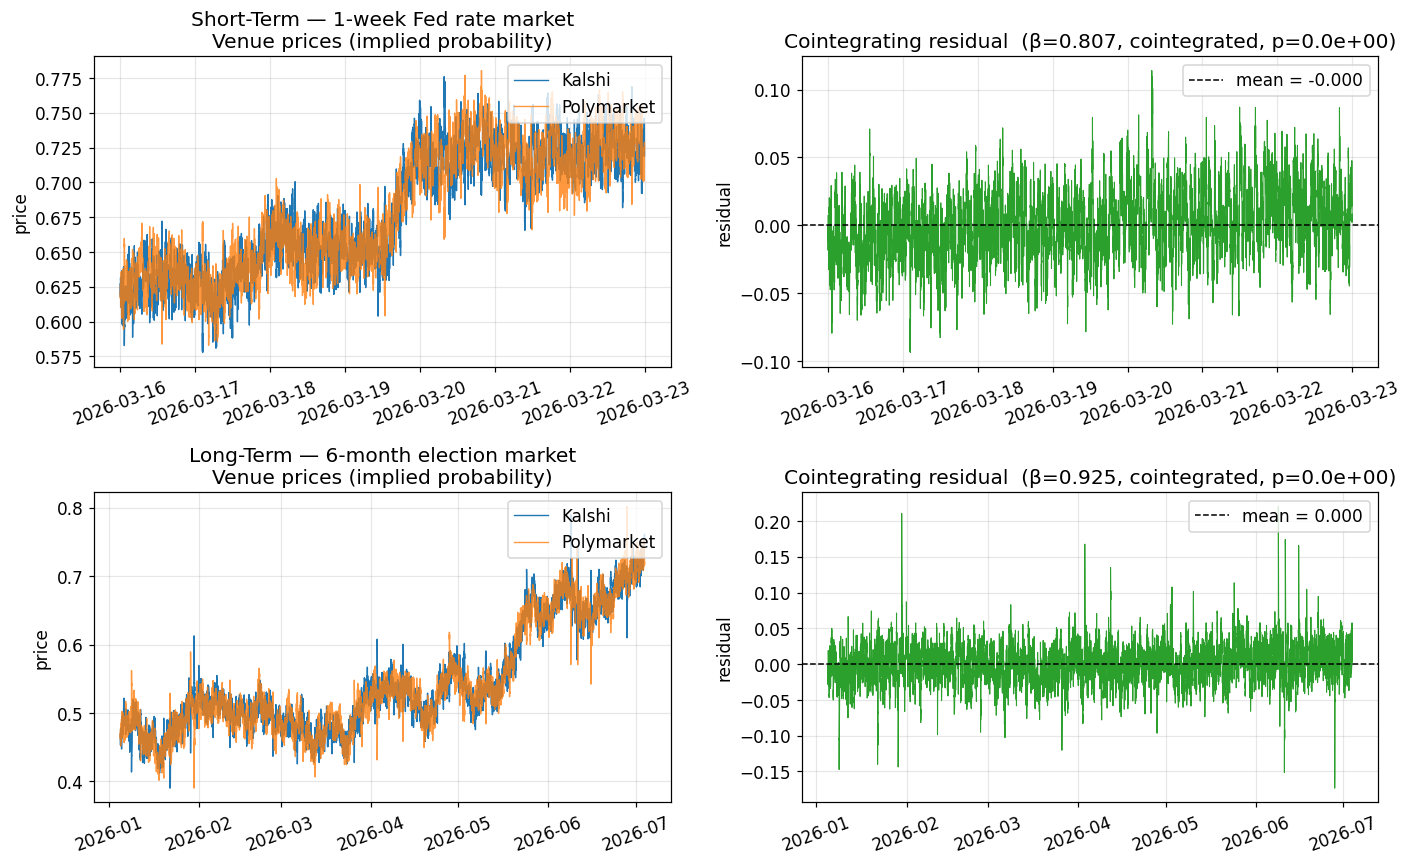

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, key in enumerate(["short_term", "long_term"]):
    lab, eg, spec = labs[key], egs[key], spec_by_key[key]
    df = lab.df

    ax = axes[i, 0]
    ax.plot(df.index, df["kalshi_price"], lw=0.9, label="Kalshi")
    ax.plot(df.index, df["polymarket_price"], lw=0.9, alpha=0.8, label="Polymarket")
    ax.set_title(f"{spec.label} — {spec.description}\nVenue prices (implied probability)")
    ax.set_ylabel("price"); ax.legend(loc="upper right")

    resid = df["kalshi_price"] - eg.alpha - eg.beta * df["polymarket_price"]
    ax = axes[i, 1]
    ax.plot(df.index, resid, lw=0.7, color="C2")
    ax.axhline(resid.mean(), color="k", ls="--", lw=1, label=f"mean = {resid.mean():.3f}")
    verdict = "cointegrated" if eg.cointegrated else "NOT cointegrated"
    ax.set_title(f"Cointegrating residual  (β={eg.beta:.3f}, {verdict}, p={eg.pvalue:.1e})")
    ax.set_ylabel("residual"); ax.legend(loc="upper right")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout(); plt.show()

## 3. The spread reverting to the mean

The tradeable signal is the **signed spread** `Kalshi − Polymarket`, standardized
into a 60-period rolling z-score. We **enter** when it stretches to ±2σ, **exit**
when it reverts to the mean (z = 0), and **stop out** if it blows past ±3.5σ.
A zoomed window shows the spread oscillating inside its ±2σ band (with entry ▲ /
exit ▼ markers) and the z-score crossing its thresholds below.

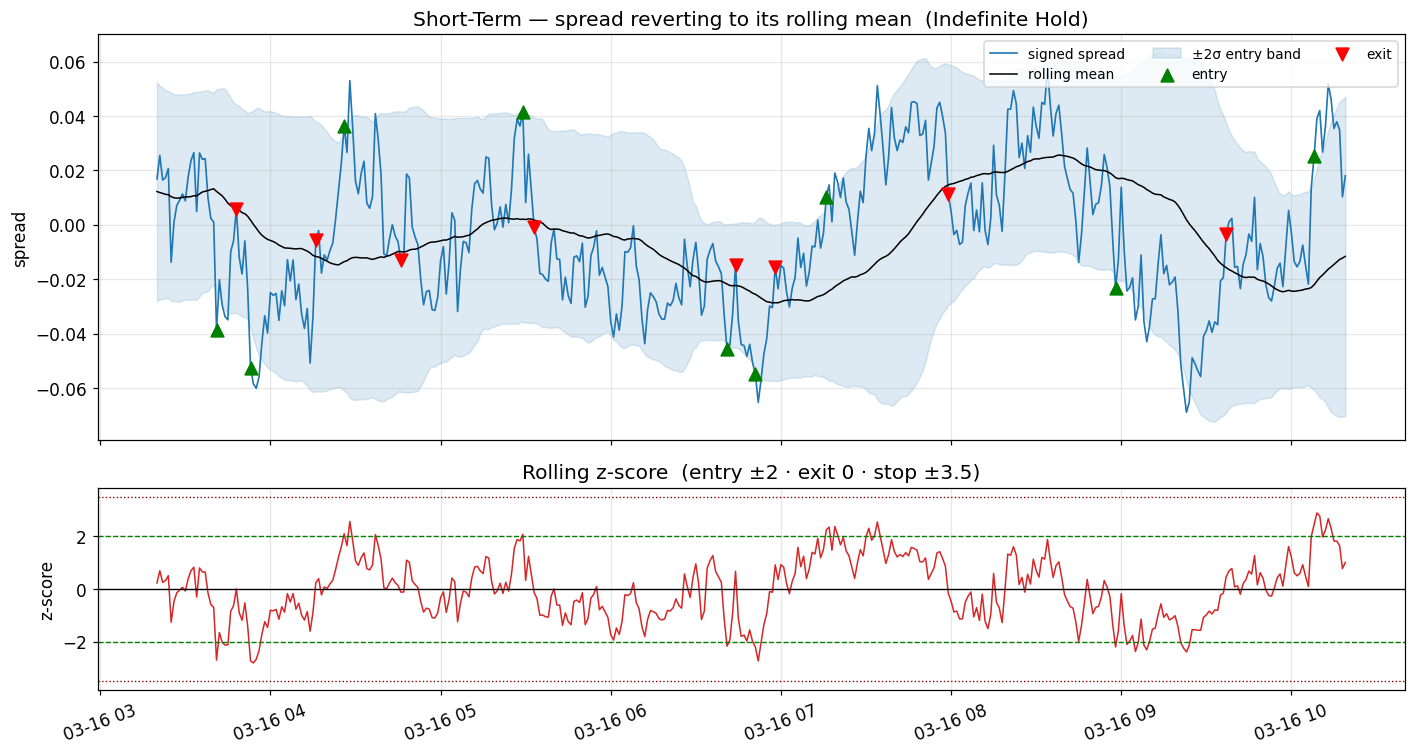

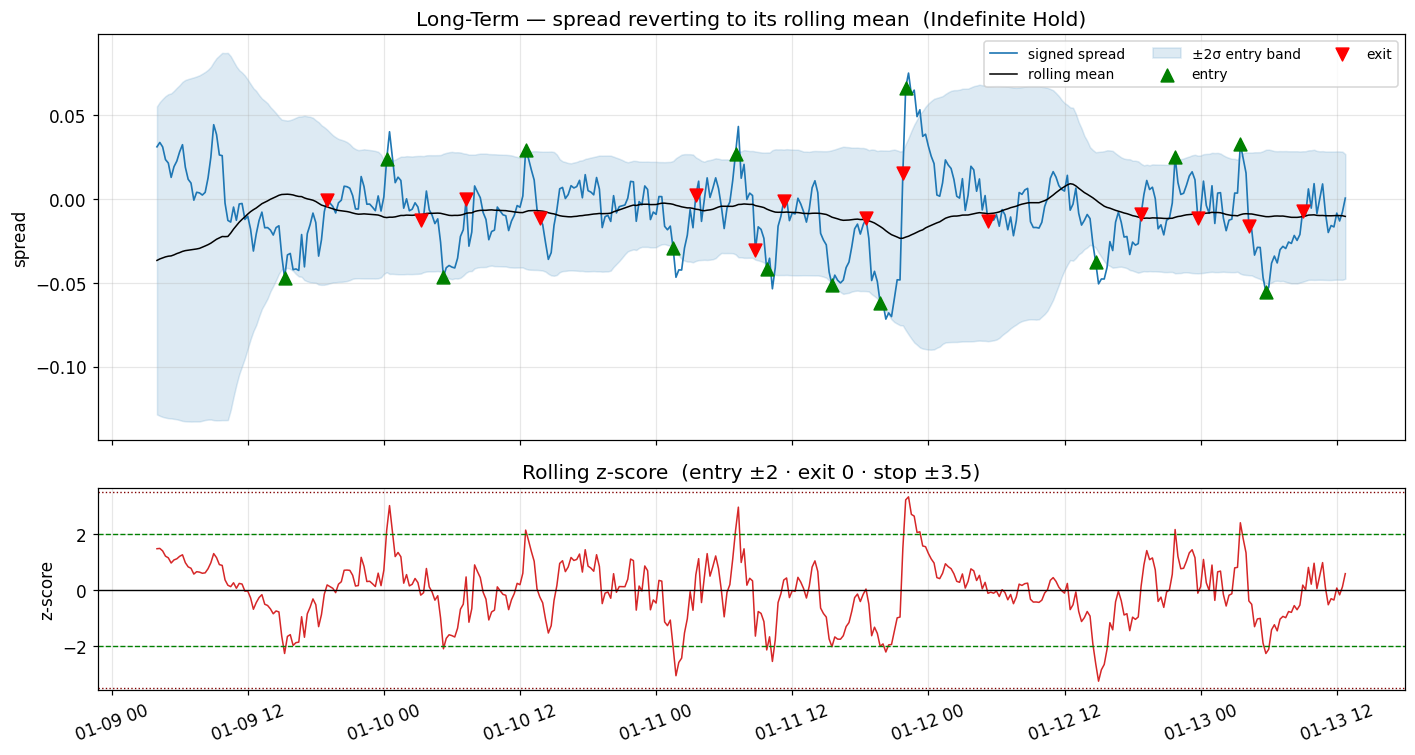

In [4]:
def plot_reversion(key, mode="indefinite_hold", start=300, n=420):
    lab, spec = labs[key], spec_by_key[key]
    sig = signals[(key, mode)]
    zf = lab.rolling_zscore(window=WINDOW, spread=lab.signed_spread)
    sl = slice(start, start + n)
    z, s = zf.iloc[sl], sig.iloc[sl]
    upper = z["rolling_mean"] + ENTRY_Z * z["rolling_std"]
    lower = z["rolling_mean"] - ENTRY_Z * z["rolling_std"]

    fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 7),
                                 gridspec_kw={"height_ratios": [2, 1]})
    a1.plot(z.index, z["spread"], lw=1.1, label="signed spread")
    a1.plot(z.index, z["rolling_mean"], color="k", lw=1, label="rolling mean")
    a1.fill_between(z.index, lower, upper, color="C0", alpha=0.15, label="±2σ entry band")
    ent = s[s["trade_event"].str.startswith("ENTER")]
    ex  = s[s["trade_event"].isin(["EXIT", "STOP LOSS"])]
    a1.scatter(ent.index, z["spread"].reindex(ent.index), marker="^", s=70, color="green", zorder=5, label="entry")
    a1.scatter(ex.index,  z["spread"].reindex(ex.index),  marker="v", s=70, color="red",   zorder=5, label="exit")
    a1.set_title(f"{spec.label} — spread reverting to its rolling mean  ({MODE_LABELS[mode]})")
    a1.set_ylabel("spread"); a1.legend(loc="upper right", ncol=3, fontsize=9)

    a2.plot(z.index, z["zscore"], color="C3", lw=1)
    for lvl, c, ls in [(0, "k", "-"), (ENTRY_Z, "green", "--"), (-ENTRY_Z, "green", "--"),
                       (STOP_Z, "maroon", ":"), (-STOP_Z, "maroon", ":")]:
        a2.axhline(lvl, color=c, ls=ls, lw=0.9)
    a2.set_ylabel("z-score"); a2.set_title("Rolling z-score  (entry ±2 · exit 0 · stop ±3.5)")
    a2.tick_params(axis="x", rotation=20)
    fig.tight_layout(); plt.show()

plot_reversion("short_term", start=200, n=420)
plot_reversion("long_term", start=400, n=420)

## 4. Equity curves — the four backtests

Equity (top) and drawdown (bottom) for both markets, with the two risk modes
overlaid. Equity is additive P&L on a unit capital base (starts at 1.0); the
Sharpe is annualized from daily returns (risk-free = 0 %, 252 days).

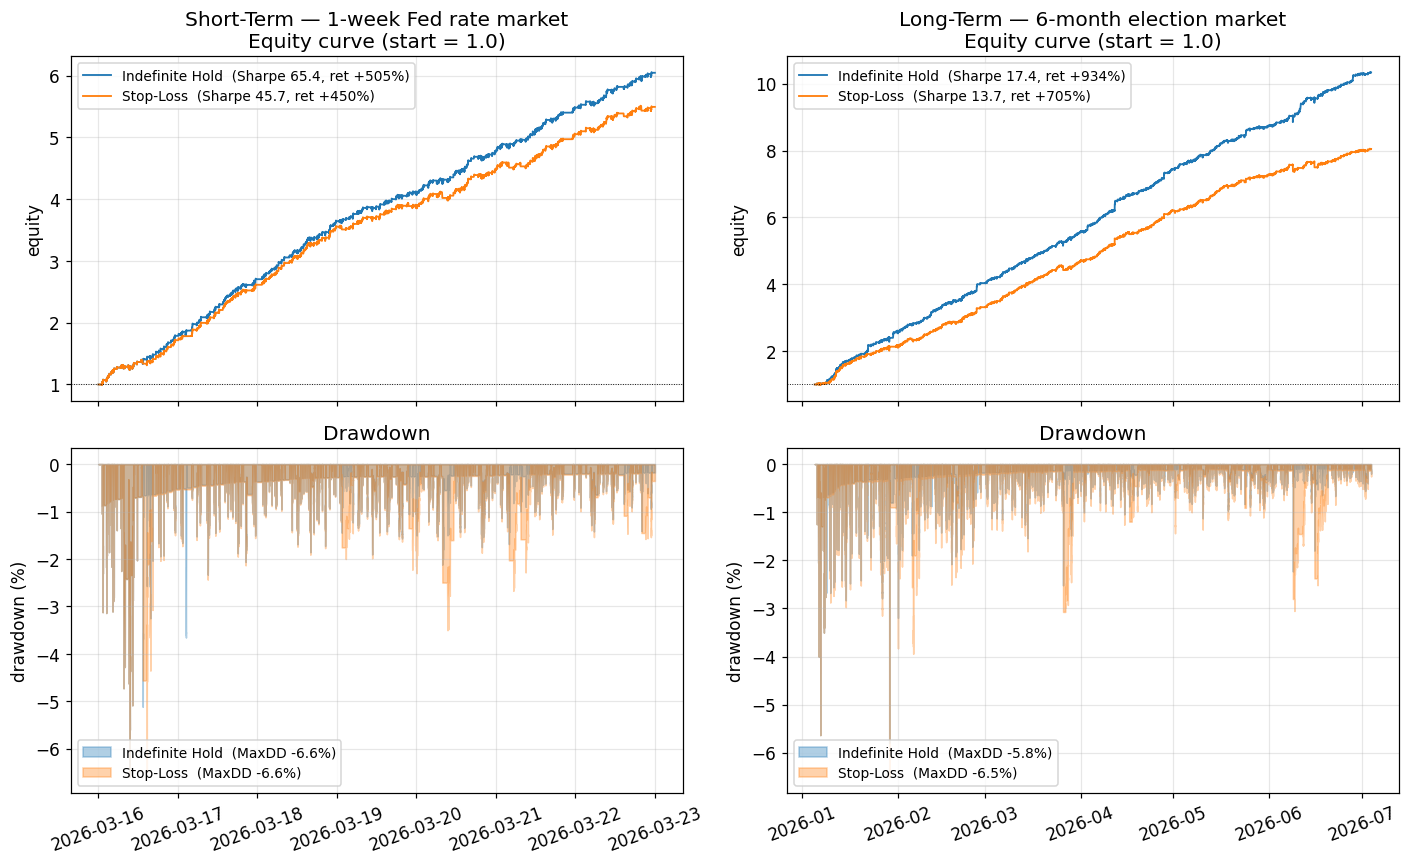

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col")
colors = {"indefinite_hold": "C0", "stop_loss": "C1"}
for j, key in enumerate(["short_term", "long_term"]):
    spec = spec_by_key[key]
    axE, axD = axes[0, j], axes[1, j]
    for mode in MODES:
        r = results[(key, mode)]
        axE.plot(r.equity_curve.index, r.equity_curve.values, color=colors[mode], lw=1.2,
                 label=f"{MODE_LABELS[mode]}  (Sharpe {r.sharpe:.1f}, ret {r.total_return:+.0%})")
        axD.fill_between(r.drawdown_curve.index, r.drawdown_curve.values * 100, 0,
                         color=colors[mode], alpha=0.35,
                         label=f"{MODE_LABELS[mode]}  (MaxDD {r.max_drawdown:.1%})")
    axE.axhline(1.0, color="k", lw=0.6, ls=":")
    axE.set_title(f"{spec.label} — {spec.description}\nEquity curve (start = 1.0)")
    axE.set_ylabel("equity"); axE.legend(loc="upper left", fontsize=9)
    axD.set_title("Drawdown"); axD.set_ylabel("drawdown (%)")
    axD.legend(loc="lower left", fontsize=9); axD.tick_params(axis="x", rotation=20)
fig.tight_layout(); plt.show()

## 5. Results summary — the 2×2 matrix

In [6]:
rows = []
for key in ["short_term", "long_term"]:
    for mode in MODES:
        r = results[(key, mode)]
        rows.append({"Dataset": spec_by_key[key].label, "Risk Mode": MODE_LABELS[mode],
                     "Total Return": f"{r.total_return:+.1%}", "Ann. Sharpe": f"{r.sharpe:.2f}",
                     "Max Drawdown": f"{r.max_drawdown:.1%}", "Trades": f"{r.n_trades:,}"})
summary = pd.DataFrame(rows).set_index(["Dataset", "Risk Mode"])
summary

Total Return Ann. Sharpe Max Drawdown Trades
Dataset    Risk Mode                                                   
Short-Term Indefinite Hold      +504.7%       65.43        -6.6%    442
           Stop-Loss            +449.5%       45.67        -6.6%    440
Long-Term  Indefinite Hold      +933.5%       17.36        -5.8%    729
           Stop-Loss            +704.6%       13.73        -6.5%    703

### Takeaways

- **Indefinite Hold beats Stop-Loss on every metric, in both markets.** With a
  *rolling-mean* z-score the strategy self-corrects (the mean adapts to a
  dislocation within the window), so most adverse moves revert — the stop merely
  exits early, books the loss, and pays a second round of fees. A stop-loss earns
  its keep only against *non-reverting* breaks (overnight gap risk,
  decointegration) that a rolling window cannot absorb.
- **Synthetic caveat:** AR(1) data is far cleaner than live markets, so the
  absolute Sharpe levels are optimistic. The *relative* ranking across the four
  scenarios is the meaningful result.